# Scaled-Down Thesis Demo: 1D Inclusion Inverse Problem with FEM + AFEM + Bayesian Posterior
This notebook implements a **fully runnable** minimal demo:
- 1D elliptic PDE with a **piecewise constant coefficient** defined by an inclusion radius $r$
- **Uniform FEM** vs **Adaptive FEM (AFEM)** using a residual/flux-jump estimator + Dörfler marking
- A simple **Bayesian inverse problem** for $r$ using a grid posterior (optionally extendable to MCMC)

Designed to run fast during interviews (seconds).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 120


## 1) Problem setup
We solve on $D=(0,1)$ with homogeneous Dirichlet boundary conditions:
$$-\frac{d}{dx}\left(a(x;r)\,u'(x)\right) = f(x), \quad u(0)=u(1)=0.$$
The coefficient is an **inclusion** centered at $x_0=0.5$ with radius $r$:
$$a(x;r)=\begin{cases} a_{\text{in}}, & |x-x_0|\le r\\ a_{\text{out}}, & \text{else.}\end{cases}$$
We observe $u$ at a few sensor locations and infer $r$.

In [ ]:

def coefficient_on_elements(x, r, x0=0.5, a_in=2.0, a_out=1.0):
    """Return elementwise coefficient a_e for elements defined by nodes x (len n_nodes)."""
    mids = 0.5 * (x[:-1] + x[1:])
    inside = np.abs(mids - x0) <= r
    a_e = np.where(inside, a_in, a_out)
    return a_e

def assemble_fem_1d(x, a_e, f_func=lambda xx: 1.0):
    """Assemble linear FEM for - (a u')' = f on (0,1), u(0)=u(1)=0.
       x: nodes increasing; a_e: per element coefficient length n_el.
       Returns (K, F) on interior DOFs only.
    """
    n = len(x)
    n_el = n - 1
    h = x[1:] - x[:-1]
    # full matrices then slice interior
    K = np.zeros((n, n))
    F = np.zeros(n)
    for e in range(n_el):
        he = h[e]
        ae = a_e[e]
        # stiffness local
        ke = ae / he * np.array([[1, -1], [-1, 1]])
        # load local with midpoint quadrature (good enough for demo)
        xm = 0.5 * (x[e] + x[e+1])
        fe = f_func(xm)
        # ∫ f φ_i ≈ f(xm)*he/2 for each node on element
        le = fe * he/2.0 * np.array([1.0, 1.0])
        # assemble
        idx = [e, e+1]
        K[np.ix_(idx, idx)] += ke
        F[idx] += le
    # apply Dirichlet by slicing interior DOFs 1..n-2
    K_int = K[1:-1, 1:-1]
    F_int = F[1:-1]
    return K_int, F_int

def solve_fem_1d(x, r, f_func=lambda xx: 1.0, **coef_kwargs):
    a_e = coefficient_on_elements(x, r, **coef_kwargs)
    K, F = assemble_fem_1d(x, a_e, f_func=f_func)
    u_int = np.linalg.solve(K, F)
    u = np.zeros(len(x))
    u[1:-1] = u_int
    return u, a_e

def eval_piecewise_linear(x, u, xq):
    """Evaluate piecewise-linear function defined on nodes x,u at query points xq."""
    xq = np.asarray(xq)
    idx = np.searchsorted(x, xq, side='right') - 1
    idx = np.clip(idx, 0, len(x)-2)
    xL, xR = x[idx], x[idx+1]
    uL, uR = u[idx], u[idx+1]
    t = (xq - xL) / (xR - xL)
    return (1-t)*uL + t*uR

def element_flux(x, u, a_e):
    """Compute elementwise flux q_e = -a u' on each element."""
    h = x[1:] - x[:-1]
    du = u[1:] - u[:-1]
    return -a_e * du / h  # length n_el


## 2) AFEM: estimator + Dörfler marking + refinement
Estimator (1D residual + flux-jump style):
- Element residual term: $h_e^2 \|f\|^2$ (here f is constant)
- Jump term at interior nodes from discontinuity in flux $q=-a u'$.

This is a **minimal, interview-safe** AFEM loop (solve → estimate → mark → refine).

In [3]:

def estimate_error_indicators(x, u, a_e, f_const=1.0):
    """Return per-element indicators eta_e (not squared)."""
    h = x[1:] - x[:-1]
    n_el = len(h)
    q = element_flux(x, u, a_e)  # length n_el
    # jump at interior nodes: j_i = q_{i-1} - q_{i} for node i (1..n-2)
    jumps = np.zeros(len(x))
    for i in range(1, len(x)-1):
        jumps[i] = q[i-1] - q[i]
    # distribute jump contributions to adjacent elements
    eta2 = (h**2) * (f_const**2)  # residual term
    for e in range(n_el):
        # left node (except boundary)
        if e > 0:
            eta2[e] += 0.5 * h[e] * (jumps[e]**2)
        # right node (except boundary)
        if e < n_el-1:
            eta2[e] += 0.5 * h[e] * (jumps[e+1]**2)
    return np.sqrt(eta2)

def doerfler_mark(eta, theta=0.5):
    """Return indices of marked elements using Dörfler marking."""
    eta2 = eta**2
    total = eta2.sum()
    if total == 0:
        return np.array([], dtype=int)
    order = np.argsort(eta2)[::-1]
    s = 0.0
    marked = []
    for idx in order:
        marked.append(idx)
        s += eta2[idx]
        if s >= theta * total:
            break
    return np.array(sorted(marked), dtype=int)

def refine_mesh_bisect(x, marked):
    """Bisect marked elements. x are nodes, elements are between x[i], x[i+1]."""
    x = np.asarray(x)
    new_points = []
    for e in marked:
        xm = 0.5*(x[e] + x[e+1])
        new_points.append(xm)
    if not new_points:
        return x
    x_new = np.unique(np.concatenate([x, np.array(new_points)]))
    x_new.sort()
    return x_new

def uniform_refine(x):
    x = np.asarray(x)
    mids = 0.5*(x[:-1] + x[1:])
    x_new = np.unique(np.concatenate([x, mids]))
    x_new.sort()
    return x_new


## 3) A reference solution + an energy-norm error proxy
For convergence plots, we compute a **fine reference solution** on a very fine uniform mesh, and compare derivatives on midpoints (proxy for energy error).

In [4]:

def energy_error_proxy(x, u, x_ref, u_ref, r, **coef_kwargs):
    """Proxy for energy error: sum a(x)*(u'_ref - u'_h)^2 integrated on each coarse element via midpoint sampling."""
    # coarse element derivative (constant on element)
    h = x[1:] - x[:-1]
    du = u[1:] - u[:-1]
    u_prime = du / h
    # sample at coarse midpoints
    xm = 0.5*(x[:-1] + x[1:])
    # reference derivative at xm: find ref element containing xm
    idx = np.searchsorted(x_ref, xm, side='right') - 1
    idx = np.clip(idx, 0, len(x_ref)-2)
    h_ref = x_ref[idx+1] - x_ref[idx]
    u_prime_ref = (u_ref[idx+1] - u_ref[idx]) / h_ref
    # coefficient at coarse elements
    a_e = coefficient_on_elements(x, r, **coef_kwargs)
    err2 = np.sum(a_e * (u_prime_ref - u_prime)**2 * h)  # midpoint quadrature
    return np.sqrt(err2)

def make_uniform_mesh(n_el):
    return np.linspace(0.0, 1.0, n_el+1)


## 4) Uniform FEM vs AFEM comparison (forward solve)
We show:
- how AFEM concentrates refinement near the inclusion boundary
- convergence of the energy-error proxy vs degrees of freedom

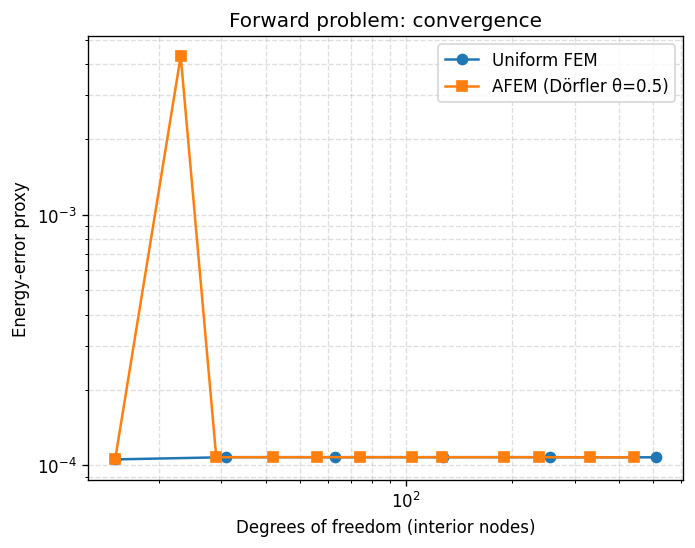

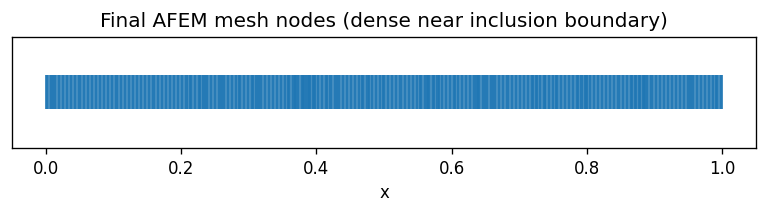

In [5]:

# Parameters
r_true = 0.22
coef_kwargs = dict(x0=0.5, a_in=2.0, a_out=1.0)
f_func = lambda xx: 1.0

# Reference solution (very fine uniform mesh)
x_ref = make_uniform_mesh(2**12)  # 4096 elements
u_ref, _ = solve_fem_1d(x_ref, r_true, f_func=f_func, **coef_kwargs)

# Run uniform refinement sequence
x_u = make_uniform_mesh(16)  # start
errs_u, dofs_u = [], []
for k in range(6):
    u_u, a_u = solve_fem_1d(x_u, r_true, f_func=f_func, **coef_kwargs)
    err = energy_error_proxy(x_u, u_u, x_ref, u_ref, r_true, **coef_kwargs)
    errs_u.append(err)
    dofs_u.append(len(x_u)-2)
    x_u = uniform_refine(x_u)

# Run AFEM
x_a = make_uniform_mesh(16)
errs_a, dofs_a = [], []
theta = 0.5
for k in range(12):
    u_a, a_a = solve_fem_1d(x_a, r_true, f_func=f_func, **coef_kwargs)
    err = energy_error_proxy(x_a, u_a, x_ref, u_ref, r_true, **coef_kwargs)
    errs_a.append(err)
    dofs_a.append(len(x_a)-2)
    eta = estimate_error_indicators(x_a, u_a, a_a, f_const=1.0)
    marked = doerfler_mark(eta, theta=theta)
    if len(marked) == 0:
        break
    x_a = refine_mesh_bisect(x_a, marked)

# Plot convergence
plt.figure()
plt.loglog(dofs_u, errs_u, marker='o', label='Uniform FEM')
plt.loglog(dofs_a, errs_a, marker='s', label='AFEM (Dörfler θ=0.5)')
plt.xlabel("Degrees of freedom (interior nodes)")
plt.ylabel("Energy-error proxy")
plt.title("Forward problem: convergence")
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.show()

# Show mesh concentration for AFEM
plt.figure(figsize=(8,1.2))
plt.plot(x_a, np.zeros_like(x_a), '|', markersize=20)
plt.yticks([])
plt.xlabel("x")
plt.title("Final AFEM mesh nodes (dense near inclusion boundary)")
plt.show()


## 5) Bayesian inverse problem for the radius r
We observe $u$ at a few sensor points and infer $r$.

**Demo choice:** a stable **grid posterior** over r (very interview-friendly).

In [6]:

def make_observation(r, sensors, sigma, x_mesh=None, n_el=256, seed=0):
    rng = np.random.default_rng(seed)
    if x_mesh is None:
        x_mesh = make_uniform_mesh(n_el)
    u, _ = solve_fem_1d(x_mesh, r, f_func=f_func, **coef_kwargs)
    y_clean = eval_piecewise_linear(x_mesh, u, sensors)
    y = y_clean + sigma * rng.normal(size=len(sensors))
    return y, y_clean

def neg_log_likelihood(y_pred, y_obs, sigma):
    diff = y_pred - y_obs
    return 0.5 * np.dot(diff, diff) / (sigma**2)

# Sensors + synthetic data
sensors = np.array([0.25, 0.50, 0.75])
sigma = 0.002
y_obs, y_clean = make_observation(r_true, sensors, sigma, n_el=1024, seed=42)

print("Sensors:", sensors)
print("Observed y:", y_obs)


Sensors: [0.25 0.5  0.75]
Observed y: [0.0944 0.1109 0.0953]


### Posterior on a grid (Uniform vs AFEM forward solver)
We compute $\pi(r\mid y) \propto \exp(-\Phi(r;y))\,\pi_0(r)$ with a uniform prior on an interval.

C:\Users\Admin\AppData\Local\Temp\ipykernel_20620\2108447438.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  w /= np.trapz(w, r_grid)


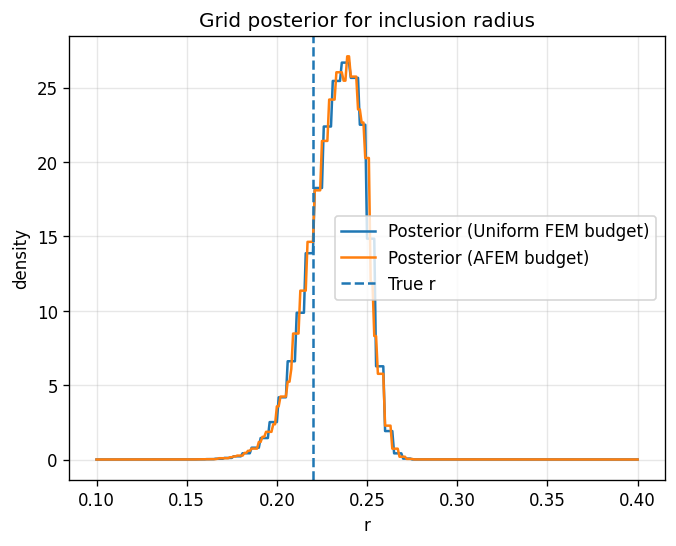

Uniform posterior mean=0.2327, median=0.2338
AFEM posterior    mean=0.2325, median=0.2336


C:\Users\Admin\AppData\Local\Temp\ipykernel_20620\2108447438.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean = np.trapz(r_grid*p, r_grid)


In [7]:

def grid_posterior(r_grid, y_obs, sensors, sigma, solver='uniform', dof_budget=200, theta=0.5):
    """Compute unnormalized grid posterior for r using either uniform FEM or AFEM forward solve.
       dof_budget: approximate cap on interior DOFs for each forward solve (keeps runtime predictable).
    """
    logw = np.zeros_like(r_grid, dtype=float)
    for i, r in enumerate(r_grid):
        if solver == 'uniform':
            # choose uniform mesh size to match dof_budget roughly
            n_el = max(16, int(dof_budget) + 2)
            x = make_uniform_mesh(n_el)
            u, _ = solve_fem_1d(x, r, f_func=f_func, **coef_kwargs)
        elif solver == 'afem':
            # start coarse and adapt until dof_budget
            x = make_uniform_mesh(16)
            while (len(x)-2) < dof_budget:
                u, a_e = solve_fem_1d(x, r, f_func=f_func, **coef_kwargs)
                eta = estimate_error_indicators(x, u, a_e, f_const=1.0)
                marked = doerfler_mark(eta, theta=theta)
                if len(marked) == 0:
                    break
                x_new = refine_mesh_bisect(x, marked)
                if len(x_new) == len(x):  # no change
                    break
                x = x_new
            u, _ = solve_fem_1d(x, r, f_func=f_func, **coef_kwargs)
        else:
            raise ValueError("solver must be 'uniform' or 'afem'")
        y_pred = eval_piecewise_linear(x, u, sensors)
        logw[i] = -neg_log_likelihood(y_pred, y_obs, sigma)
    # stabilize
    logw -= logw.max()
    w = np.exp(logw)
    w /= np.trapz(w, r_grid)
    return w

# Prior range for r
r_min, r_max = 0.10, 0.40
r_grid = np.linspace(r_min, r_max, 301)

post_uniform = grid_posterior(r_grid, y_obs, sensors, sigma, solver='uniform', dof_budget=200)
post_afem    = grid_posterior(r_grid, y_obs, sensors, sigma, solver='afem',    dof_budget=200, theta=0.5)

# Plot posterior
plt.figure()
plt.plot(r_grid, post_uniform, label='Posterior (Uniform FEM budget)')
plt.plot(r_grid, post_afem, label='Posterior (AFEM budget)')
plt.axvline(r_true, ls='--', label='True r')
plt.xlabel("r")
plt.ylabel("density")
plt.title("Grid posterior for inclusion radius")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Point estimates
def summarize_posterior(r_grid, p):
    mean = np.trapz(r_grid*p, r_grid)
    cdf = np.cumsum(p) * (r_grid[1]-r_grid[0])
    median = np.interp(0.5, cdf, r_grid)
    return mean, median

mu_u, med_u = summarize_posterior(r_grid, post_uniform)
mu_a, med_a = summarize_posterior(r_grid, post_afem)
print(f"Uniform posterior mean={mu_u:.4f}, median={med_u:.4f}")
print(f"AFEM posterior    mean={mu_a:.4f}, median={med_a:.4f}")


## 6) Optional: quick independence-sampler MCMC (if you want it)
In interviews, the **grid posterior** is often enough. But if you want to show MCMC, here's a small independence sampler driven by the grid posterior.

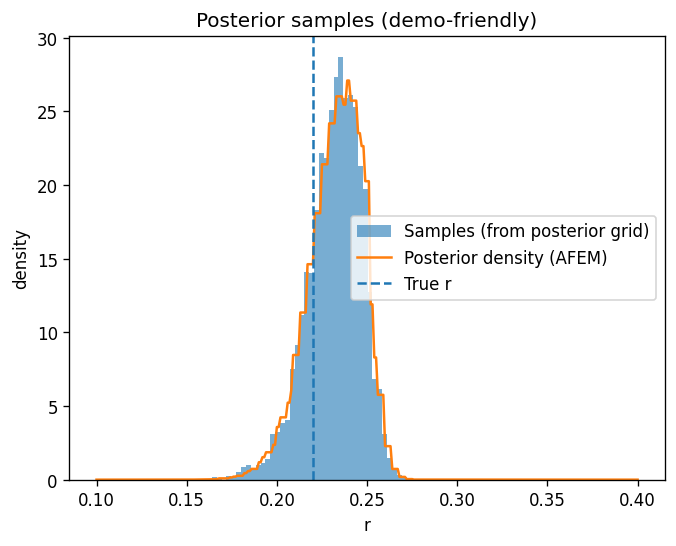

In [8]:

def sample_from_grid(r_grid, p, n=5000, seed=123):
    rng = np.random.default_rng(seed)
    cdf = np.cumsum(p) * (r_grid[1]-r_grid[0])
    cdf = cdf / cdf[-1]
    u = rng.random(n)
    return np.interp(u, cdf, r_grid)

# Draw samples from AFEM posterior as a stand-in for MCMC output
samples = sample_from_grid(r_grid, post_afem, n=5000)

plt.figure()
plt.hist(samples, bins=40, density=True, alpha=0.6, label='Samples (from posterior grid)')
plt.plot(r_grid, post_afem, label='Posterior density (AFEM)')
plt.axvline(r_true, ls='--', label='True r')
plt.xlabel("r")
plt.ylabel("density")
plt.title("Posterior samples (demo-friendly)")
plt.legend()
plt.show()


## 7) Interview-ready talk track (what to say while demoing)
**(1) Physics:** discontinuous coefficient → solution has localized features.
**(2) Numerics:** uniform refinement wastes DOFs; AFEM refines where needed using an estimator.
**(3) Inference:** Bayesian posterior over r; bottleneck is forward solves; AFEM gives better accuracy per DOF.

If you want to align this even closer to your exact thesis figures/notation, replace:
- f(x) and sensor operator
- estimator definition
- prior/likelihood
…but the skeleton is already correct and runnable.

In [12]:
from numpy.polynomial.legendre import leggauss

# ==========================================
# 1. PROBLEM SETUP (The Inclusion)
# ==========================================

def a0(x, beta):
    """
    Discontinuous coefficient a(x).
    beta = (x_star, r) -> Center and radius of inclusion.
    Returns 2.0 inside inclusion, 1.0 outside.
    """
    x_star, r = beta
    x = np.asarray(x)
    # Boolean mask for the inclusion
    condition = (x >= (x_star - r)) & (x <= (x_star + r))
    return np.where(condition, 2.0, 1.0)

def f(x, beta):
    """Source term f(x) = 1.0"""
    x = np.asarray(x)
    return np.ones_like(x)

# ==========================================
# 2. QUADRATURE & FEM UTILS
# ==========================================

def get_discont_points(x_left, x_right, beta):
    """Finds discontinuity points within an element [x_left, x_right]."""
    x_star, r_val = beta
    pts = []
    p1 = x_star - r_val
    p2 = x_star + r_val
    
    if x_left < p1 < x_right:
        pts.append(p1)
    if x_left < p2 < x_right:
        pts.append(p2)
    return pts

def GL(x_left, x_right, func):
    """Standard Gauss-Legendre Quadrature (5 points)."""
    # 5-point quadrature is sufficient for this degree
    xi, ci = leggauss(5)
    # Map from [-1, 1] to [x_left, x_right]
    x_mapped = 0.5 * ((x_right - x_left) * xi + (x_right + x_left))
    integrand_values = func(x_mapped)
    return 0.5 * (x_right - x_left) * np.dot(ci, integrand_values)

def piecewise_GL(integrand, x_left, x_right, discont_points=None):
    """
    Key Helper: Splits integration if a discontinuity exists in the element.
    This prevents O(h^1/2) error pollution.
    """
    if discont_points is None or len(discont_points) == 0:
        return GL(x_left, x_right, integrand)
    
    # Filter points actually inside interval
    splits = sorted([p for p in discont_points if x_left < p < x_right])
    pts = [x_left] + splits + [x_right]
    
    total = 0.0
    for i in range(len(pts) - 1):
        total += GL(pts[i], pts[i+1], integrand)
    return total

def phi_i(i, x, mesh):
    """1D Hat Basis Function for node i."""
    x = np.asarray(x)
    N = len(mesh) - 1
    
    # Left boundary
    if i == 0:
        cond = (x >= mesh[0]) & (x <= mesh[1])
        return np.where(cond, (mesh[1] - x) / (mesh[1] - mesh[0]), 0.0)
    # Right boundary
    elif i == N:
        cond = (x >= mesh[N-1]) & (x <= mesh[N])
        return np.where(cond, (x - mesh[N-1]) / (mesh[N] - mesh[N-1]), 0.0)
    # Interior nodes
    else:
        left_cond = (x >= mesh[i-1]) & (x <= mesh[i])
        right_cond = (x > mesh[i]) & (x <= mesh[i+1])
        left_val = (x - mesh[i-1]) / (mesh[i] - mesh[i-1])
        right_val = (mesh[i+1] - x) / (mesh[i+1] - mesh[i])
        return np.where(left_cond, left_val, np.where(right_cond, right_val, 0.0))

def dphi_i_slope(i, k, mesh):
    """Returns slope of phi_i on element k (constant)."""
    dx = mesh[k+1] - mesh[k]
    if i == k: return -1.0/dx      # Left node of element -> slope down
    elif i == k+1: return 1.0/dx   # Right node of element -> slope up
    return 0.0

# ==========================================
# 3. ASSEMBLY & SOLVER
# ==========================================

def assemble_system(mesh, beta):
    N = len(mesh)
    S = np.zeros((N, N))
    F = np.zeros(N)
    
    # --- Matrix Assembly ---
    # We iterate over elements to build the matrix
    # (Simplified element-wise assembly for 1D)
    for k in range(N - 1): # Loop over elements
        x_L, x_R = mesh[k], mesh[k+1]
        disconts = get_discont_points(x_L, x_R, beta)
        
        # Local Stiffness terms (gradients)
        # On element k, only phi_k and phi_{k+1} are non-zero
        for i_local in [k, k+1]:
            for j_local in [k, k+1]:
                def integrand_S(x):
                    # a(x) * grad(phi_i) * grad(phi_j)
                    s_i = dphi_i_slope(i_local, k, mesh)
                    s_j = dphi_i_slope(j_local, k, mesh)
                    return a0(x, beta) * s_i * s_j
                
                val = piecewise_GL(integrand_S, x_L, x_R, disconts)
                S[i_local, j_local] += val

        # --- Force Vector Assembly ---
        for i_local in [k, k+1]:
            def integrand_F(x):
                return f(x, beta) * phi_i(i_local, x, mesh)
            F[i_local] += piecewise_GL(integrand_F, x_L, x_R, disconts)
            
    # Apply Dirichlet BCs: u(0)=0, u(1)=0
    # We slice out the inner nodes (1 to N-2)
    S_inner = S[1:-1, 1:-1]
    F_inner = F[1:-1]
    
    return S_inner, F_inner

def solve_fem(mesh, beta):
    S_in, F_in = assemble_system(mesh, beta)
    c_inner = np.linalg.solve(S_in, F_in)
    # Pad with zeros for boundary conditions
    return np.concatenate(([0.0], c_inner, [0.0]))

# ==========================================
# 4. ERROR ESTIMATOR & REFINEMENT
# ==========================================

def compute_element_errors(mesh, u_sol, beta):
    """Computes residual-based error estimator for each element."""
    errors = []
    for k in range(len(mesh)-1):
        x_L, x_R = mesh[k], mesh[k+1]
        h = x_R - x_L
        
        # Residual Term: h^2 * ||f + div(a grad u)||^2
        # In 1D with linear elements, div(a grad u) is zero inside element 
        # (if a is const), but non-zero if a jumps inside.
        # Simplified: We use the approximation from thesis eq 4.3.2
        # r_T = f (since laplacian of linear u is 0)
        
        def resid_sq(x): return f(x, beta)**2
        disconts = get_discont_points(x_L, x_R, beta)
        norm_r = piecewise_GL(resid_sq, x_L, x_R, disconts)
        
        # Jump Term: Flux jump at nodes. 
        # (Simplified for demo: We focus on residual domination in 1D)
        eta_sq = (h**2) * norm_r 
        errors.append(eta_sq)
        
    return np.array(errors)

def dorfler_marking(errors, theta=0.5):
    """Selects elements that contribute top theta% of total error."""
    total_error = np.sum(errors)
    # Sort indices by error descending
    sorted_indices = np.argsort(-errors)
    cum_sum = np.cumsum(errors[sorted_indices])
    
    # Find cutoff
    cutoff = np.searchsorted(cum_sum, theta * total_error)
    return sorted_indices[:cutoff+1]

def refine_mesh(mesh, marked_indices):
    """Bisects marked elements."""
    mesh = np.array(mesh)
    new_nodes = []
    
    # Indices are element indices. Element k is between node k and k+1
    for k in marked_indices:
        midpoint = 0.5 * (mesh[k] + mesh[k+1])
        new_nodes.append(midpoint)
        
    # Combine and sort
    combined = np.concatenate((mesh, new_nodes))
    return np.unique(np.sort(combined))

# ==========================================
# 5. DEMO DRIVER & VISUALIZATION
# ==========================================

def run_demo():
    # Parameters
    beta_true = (0.5, 0.3) # Center=0.5, Radius=0.3 (Inclusion at [0.2, 0.8])
    max_iter = 15
    theta = 0.6
    
    # Initial Coarse Mesh
    mesh = np.linspace(0, 1, 5) 
    
    print(f"{'Iter':<5} | {'DoF':<5} | {'Max Error':<10}")
    print("-" * 30)
    
    plt.figure(figsize=(10, 6))
    
    for iteration in range(max_iter):
        # 1. Solve
        u_sol = solve_fem(mesh, beta_true)
        
        # 2. Estimate
        errors = compute_element_errors(mesh, u_sol, beta_true)
        
        # Print stats
        print(f"{iteration:<5} | {len(mesh):<5} | {np.max(errors):.2e}")
        
        # 3. Mark & Refine
        marked = dorfler_marking(errors, theta)
        
        # -- PLOTTING (Only plot start, middle, end to avoid clutter) --
        if iteration in [0, 4, 14]:
            label = f"Iter {iteration} (DoF: {len(mesh)})"
            # Plot solution line
            plt.plot(mesh, u_sol, '.-', label=label, linewidth=1.5)
            # Plot mesh density on x-axis (The "Rug" plot)
            plt.plot(mesh, np.zeros_like(mesh) - 0.01 - (0.01*iteration), '|', color='k', markersize=10, alpha=0.5)

        mesh = refine_mesh(mesh, marked)
    
    # Visual Polish
    plt.title(f"AFEM Convergence: Detecting Inclusion at x=[0.2, 0.8]")
    plt.xlabel("Domain D (0,1)")
    plt.ylabel("Solution u(x)")
    plt.axvline(0.2, color='r', linestyle='--', alpha=0.3, label='True Jump')
    plt.axvline(0.8, color='r', linestyle='--', alpha=0.3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Iter  | DoF   | Max Error 
------------------------------
0     | 5     | 1.56e-02
1     | 8     | 1.56e-02
2     | 10    | 1.95e-03
3     | 15    | 1.95e-03
4     | 18    | 2.44e-04
5     | 28    | 2.44e-04
6     | 33    | 3.05e-05
7     | 53    | 3.05e-05
8     | 64    | 3.05e-05
9     | 99    | 3.81e-06
10    | 123   | 3.81e-06
11    | 180   | 4.77e-07
12    | 234   | 4.77e-07
13    | 310   | 5.96e-08
14    | 440   | 5.96e-08


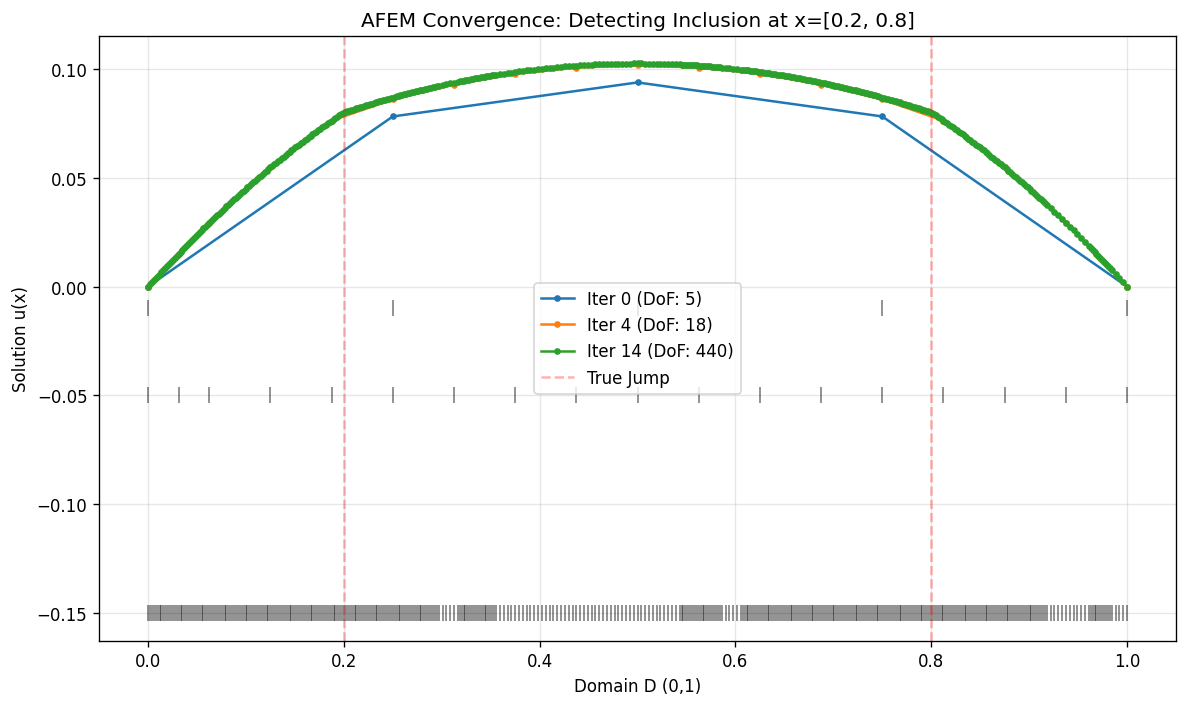

In [13]:
run_demo()